<a href="https://colab.research.google.com/github/PalQuisp/Sis420-int/blob/main/lab004_ori_b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicion de programación - Regresión Logistica

En este ejercicio se implementa regresion logistica y se aplica a dos diferentes datasets.

In [98]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [99]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

## 1 Regresion Logistica

En esta parte del ejercicio, creará un modelo de regresión logística para predecir si un estudiante será admitido en una universidad. Suponga que es el administrador de un departamento universitario y desea determinar las posibilidades de admisión de cada solicitante en función de sus resultados en dos exámenes. Tiene datos históricos de solicitantes anteriores que puede usar como un conjunto de capacitación para la regresión logística. Para cada ejemplo de capacitación, se tiene las calificaciones del solicitante en dos exámenes y la decisión de admisión. Su tarea es crear un modelo de clasificación que calcule la probabilidad de admisión de un solicitante en función de los puntajes de esos dos exámenes.

La siguiente celda cargará los datos y las etiquetas correspondientes:

In [100]:
# Cargar datos
import pandas as pd
# Las dos primeras columnas contienen la nota de dos examenes y la tercera columna
# contiene la etiqueta que indica si el alumno ingreso o no a la universidad.
#data = np.loadtxt('/content/drive/MyDrive/Colab Notebooks/machine learning/datasets/ex2data1.txt', delimiter=',')
data = pd.read_csv('/content/drive/MyDrive/machine learning/datasets/lab004.csv', delimiter=',')
# Adaptación del paso: X, y = data[:, 0:2], data[:, 2]
y = np.where(data['Attack_type'] == 'Thing_speak', 0, 1)
X_num = data.drop(columns=['Attack_type']).select_dtypes(include=[np.number])
X = X_num.iloc[:, 0:2].values  # Selecciona las 2 primeras columnas numéricas

# Esto escala las variables de RT-IoT2022 para que no saturen la sigmoide
mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)
X = (X - mu) / sigma

# 3. Concatenar la columna de unos (Tu código original de la plantilla)
m, n = X.shape
X = np.concatenate([np.ones((m, 1)), X], axis=1)

print(X)
print(y)

[[ 1.         -1.2159004   0.21120223]
 [ 1.         -1.21586757  0.8654049 ]
 [ 1.         -1.21583474  0.53075265]
 ...
 [ 1.         -1.15000851  1.29035347]
 [ 1.         -1.14997568  1.29035347]
 [ 1.         -1.14994285  1.29035347]]
[1 1 1 ... 1 1 1]


### 1.1 Visualizar los datos

Antes de comenzar a implementar cualquier algoritmo de aprendizaje, siempre es bueno visualizar los datos si es posible. Mostramos los datos en una gráfica bidimensional llamando a la función `plotData`. Se completará el código en `plotData` para que muestre una figura donde los ejes son los dos puntajes de los dos examenes, los ejemplos positivos y negativos se muestran con diferentes marcadores.

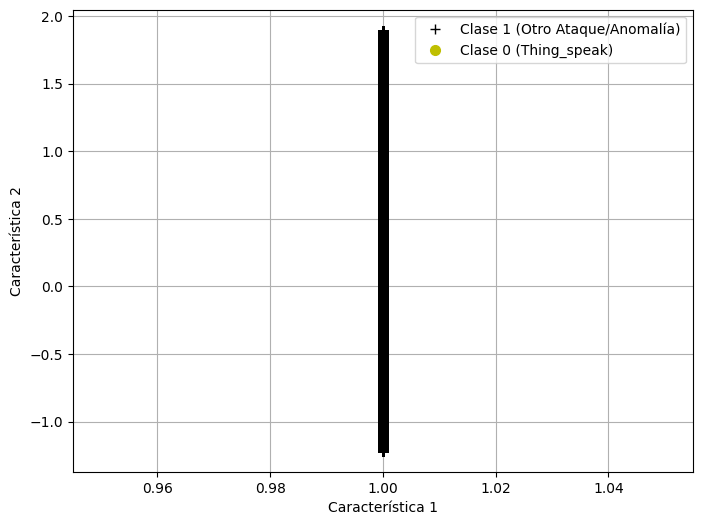

In [101]:
# Definición de la función dada por el docente
def plotData(X, y):
    fig = plt.figure(figsize=(8, 6))

    # Separar índices de ejemplos positivos (y == 1) y negativos (y == 0)
    pos = y == 1
    neg = y == 0

    # Se grafican las 2 primeras características para la representación 2D
    plt.plot(X[pos, 0], X[pos, 1], 'k+', linewidth=2, markersize=7, label='Clase 1 (Otro Ataque/Anomalía)')
    plt.plot(X[neg, 0], X[neg, 1], 'yo', markersize=7, label='Clase 0 (Thing_speak)')

    return fig

# Llamar a la función
plotData(X, y)

# Personalizar etiquetas
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


Se llama a la función implementada para mostrar los datos cargados:

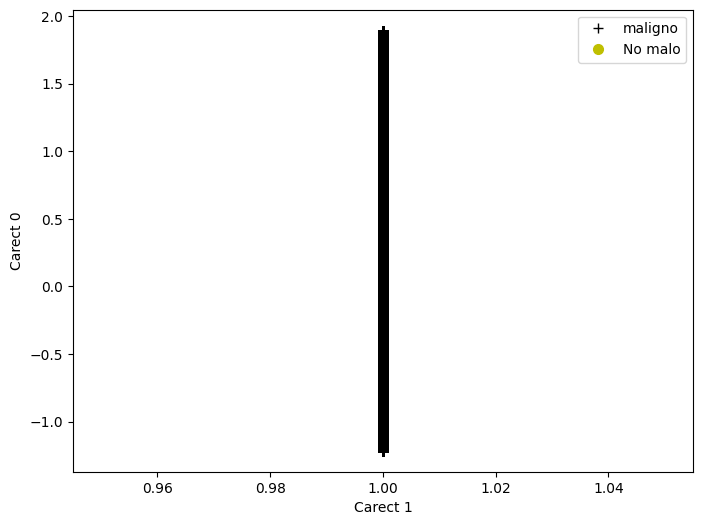

In [102]:
plotData(X, y)
# adiciona etiquetas para los ejes
pyplot.xlabel('Carect 1')
pyplot.ylabel('Carect 0')
pyplot.legend(['maligno', 'No malo'])
pass

<a id="section1"></a>
### 1.2 Implementacion

#### 1.2.1 Fución Sigmoidea

La hipotesis para la regresión logistica se define como:

$$ h_\theta(x) = g(\theta^T x)$$

donde la función $g$ is la función sigmoidea. La función sigmoidea se define como:

$$g(z) = \frac{1}{1+e^{-z}}$$.

Los resultados que debe generar la funcion sigmoidea para valores positivos amplios de `x`, deben ser cercanos a 1, mientras que para valores negativos grandes, la sigmoide debe generar valores cercanos 0. La evaluacion de `sigmoid(0)` debe dar un resultado exacto de 0.5. Esta funcion tambien debe poder trabajar con vectores y matrices.

In [103]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

Se calcula el valor de la sigmoide aplicando la funcion sigmoid con `z=0`, se debe obtener un resultado de 0.5. RE recomienda experimentar con otros valores de `z`.

In [104]:
# Prueba la implementacion de la funcion sigmoid
z = [-100, 0.5, 1000000]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [-100, 0.5, 1000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


<a id="section2"></a>
#### 1.2.2 Función de Costo y Gradiente

Se implementa la funcion cost y gradient, para la regresión logistica. Antes de continuar es importante agregar el termino de intercepcion a X.

In [105]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X.shape
# Agraga el termino de intercepción a A
X = np.concatenate([np.ones((m, 1)), X], axis=1)

La funcion de costo en una regresión logistica es:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

y el gradiente del costo es un vector de la misma longitud como $\theta$ donde el elemento $j^{th}$ (para $j = 0, 1, \cdots , n$) se define como:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

Si bien este gradiente parece idéntico al gradiente de regresión lineal, la fórmula es diferente porque la regresión lineal y logística tienen diferentes definiciones de $h_\theta(x)$.
<a id="costFunction"></a>

In [106]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [107]:
def descensoGradiente(X, y, theta, alpha, num_iters):
    # Inicializa algunos valores utiles
    m = y.size

    # realiza una copia de theta, para evitar cambiar el original dentro de la función
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        # Calcular la hipótesis usando la función sigmoid
        h = sigmoid(X.dot(theta))

        # Actualizar theta mediante el descenso por el gradiente
        theta = theta - (alpha / m) * (X.T.dot(h - y))

        # Guardar el costo en cada iteración
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

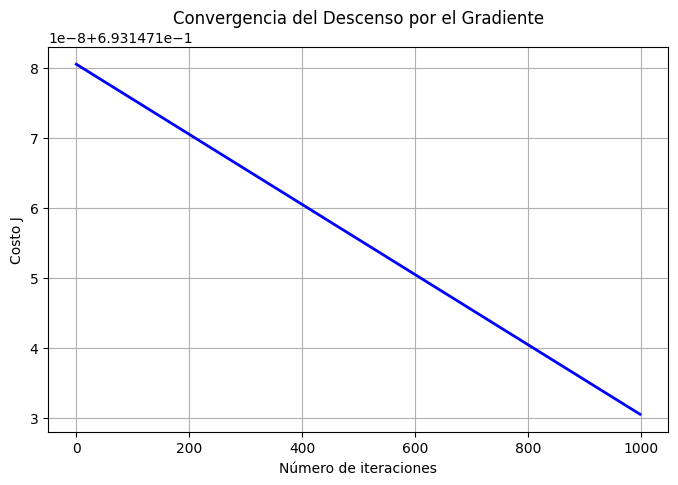

Theta calculado por el descenso por el gradiente:  [4.99999988e-08 4.99999988e-08 3.94813946e-24 2.06122352e-24]
Costo final: 0.6931


In [108]:
# Establecer el valor de la tasa de aprendizaje alpha y el número de iteraciones
alpha = 0.0000000001
num_iters = 1000

# Inicializar theta en ceros
theta = np.zeros(X.shape[1])

# Ejecutar el descenso por el gradiente
theta, J_history = descensoGradiente(X, y, theta, alpha, num_iters)

# Graficar la función de costo vs el número de iteraciones
plt.figure(figsize=(8, 5))
plt.plot(range(len(J_history)), J_history, '-b', lw=2)
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del Descenso por el Gradiente')
plt.grid(True)
plt.show()

# Mostrar el valor final de theta
print('Theta calculado por el descenso por el gradiente: ', theta)
print(f'Costo final: {J_history[-1]:.4f}')

In [111]:
X_array = [1, 30, 95,0]
y_predicted = sigmoid(np.dot(X_array, theta))
print('LA probabilidad de que este hackeado es :{:.0f}'.format(y_predicted))

LA probabilidad de que este hackeado es :1


In [115]:
def costFunction(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size

    # Recompensar el costo y gradiente
    J = 0
    grad = np.zeros(theta.shape)

    # Multiplicación directa sin .T
    h = sigmoid(X.dot(theta))

    # Tolerancia epsilon para evitar log(0) -> NaN
    e = 1e-15

    # Calcular la función de costo J
    J = (1 / m) * np.sum(-y * np.log(h + e) - (1 - y) * np.log(1 - h + e))

    # Calcular los gradientes
    grad = (1 / m) * (X.T.dot(h - y))

    return J, grad

Se prueba la funcion `costFunction` utilizando dos casos de prueba para $\theta$.

In [116]:
# Inicializacion de parametros de ajuste
initial_theta = np.zeros(n+1)
print(initial_theta)
cost, grad = costFunction(initial_theta, X, y)

print('Costo en theta inicial (zeros): {:.3f}'.format(cost))
print('Costo esperado (aproximado): 0.693\n')
print(grad)
print('Gradiente en theta inicial (zeros):')
print('\t[{:.4f}, {:.4f}, {:.4f}]'.format(*grad))
print('Gradiente esperado (aproximado):\n\t[-0.1000, -12.0092, -11.2628]\n')



[0. 0. 0. 0.]
Costo en theta inicial (zeros): 0.693
Costo esperado (aproximado): 0.693

[-5.00000000e-01 -5.00000000e-01 -4.35136511e-17  8.21415526e-18]
Gradiente en theta inicial (zeros):
	[-0.5000, -0.5000, -0.0000]
Gradiente esperado (aproximado):
	[-0.1000, -12.0092, -11.2628]



In [119]:
# Calcula y muestra el costo y el gradiente con valores de theta diferentes a cero

test_theta = np.array([-24, 0.2, 0.2, 0.1])
#test_theta = np.array([-11.74749157, 0.09927308, 0.09316497])
print(test_theta)
cost, grad = costFunction(test_theta, X, y)

print('Costo en theta prueba: {:.3f}'.format(cost))
print('Costo esperado (aproximado): 0.218\n')

print('Gradiente en theta prueba:')
print('\t[{:.3f}, {:.3f}, {:.3f}]'.format(*grad))
print('Gradiente esperado (aproximado):\n\t[0.043, 2.566, 2.647]')

[-24.    0.2   0.2   0.1]
Costo en theta prueba: 23.800
Costo esperado (aproximado): 0.218

Gradiente en theta prueba:
	[-1.000, -1.000, 0.000]
Gradiente esperado (aproximado):
	[0.043, 2.566, 2.647]


#### 1.2.3 Parámetros de aprendizaje usando `scipy.optimize`

En el codigo anterior se encontró los parámetros óptimos de un modelo de regresión lineal al implementar el descenso de gradiente. Se implemento una función de costo y se calculó su gradiente, utilizando el algoritmo del descenso por el gradiente.

En lugar de realizar los pasos del descenso por el gradiente, se utilizará el [módulo `scipy.optimize`] (https://docs.scipy.org/doc/scipy/reference/optimize.html). SciPy es una biblioteca de computación numérica para `python`. Proporciona un módulo de optimización para la búsqueda y minimización de raíces. A partir de `scipy 1.0`, la función` scipy.optimize.minimize` es el método a utilizar para problemas de optimización (tanto restringidos como no restringidos).

For logistic regression, you want to optimize the cost function $J(\theta)$ with parameters $\theta$.
Concretely, you are going to use `optimize.minimize` to find the best parameters $\theta$ for the logistic regression cost function, given a fixed dataset (of X and y values). You will pass to `optimize.minimize` the following inputs:

Para la regresión logística, se desea optimizar la función de costo $J(\theta)$ con los parámetros $\theta$.
Concretamente, se va a utilizar `optimize.minimize` para encontrar los mejores parámetros $\theta$ para la función de costo de regresión logística, dado un dataset fijo (de valores X e y). Se pasara a `optimize.minimize` las siguientes entradas:

- `costFunction`: Una función de costo que, cuando se le da el dataset de entrenamiento y un $\theta$ particular, calcula el costo de regresión logística y el gradiente con respecto a $\theta$ para el dataset(X, y). Es importante tener en cuenta que solo se pasa el nombre de la función sin el paréntesis. Esto indica que solo proporcionamos una referencia a esta función y no evaluamos el resultado de esta función.
- `initial_theta`: Los valores iniciales de los parametros que se tratan de optimizar.
- `(X, y)`: Estos son argumentos adicionales a la funcion de costo.
- `jac`: Indicación si la función de costo devuelve el jacobiano (gradiente) junto con el valor de costo. (True)
- `method`: Método / algoritmo de optimización a utilizar
- `options`: Opciones adicionales que pueden ser específicas del método de optimización específico. Solo se indica al algoritmo el número máximo de iteraciones antes de que termine.

Si se ha completado la `costFunction` correctamente,`optimize.minimize` convergerá en los parámetros de optimización correctos y devolverá los valores finales del costo y $\theta$ en un objeto de clase.

Al usar `optimize.minimize`, no se tuvo que escribir ningún bucle ni establecer una tasa de aprendizaje como se hizo para el descenso de gradientes. Todo esto se hace mediante `optimize.minimize`: solo se necesita proporcionar una función que calcule el costo y el gradiente.

A continuación, se tiene el código para llamar a `optimize.minimize` con los argumentos correctos.

In [123]:
import scipy.optimize as opt

# Establecer las opciones para optimize.minimize
options = {'maxfun': 1000}

# optimize.minimize requiere una función que reciba theta como primer argumento y retorne (costo, gradiente)
# Pasamos los datos adicionales X e y mediante el parámetro args
res = opt.minimize(fun=costFunction,
                   x0=initial_theta,
                   args=(X, y),
                   method='TNC',
                   jac=True,
                   options=options)

# Extraer el theta optimizado y el costo mínimo alcanzado
theta = res.x
cost = res.fun

# Mostrar los resultados del entrenamiento
print(f'Costo en theta encontrado por optimize.minimize: {cost:.4f}')
print('theta: ')
print(f' {theta}')

Costo en theta encontrado por optimize.minimize: 0.0000
theta: 
 [7.40645576e+00 7.40645576e+00 6.93436068e-16 3.49636974e-16]


Una vez que se completa `optimize.minimize`, se usa el valor final de $\theta$ para visualizar el límite de decisión en los datos de entrenamiento.

Para hacerlo, se implementa la función `plotDecisionBoundary` para trazar el límite de decisión sobre los datos de entrenamiento.

In [142]:
def plotDecisionBoundary(plotData, theta, X, y):
    """
    Grafica los puntos de entrenamiento y la frontera de decisión
    manejando correctamente límites constantes en las características.
    """
    # 1. Graficar los datos de entrenamiento
    plotData(X[:, 1:], y)

    # 2. Obtener min y max con un margen para evitar ejes colapsados
    x1_min, x1_max = np.min(X[:, 1]), np.max(X[:, 1])
    x2_min, x2_max = np.min(X[:, 2]), np.max(X[:, 2])

    # Si min y max son iguales, dar un rango artificial para poder graficar
    if x1_min == x1_max:
        x1_min, x1_max = x1_min - 1, x1_max + 1
    if x2_min == x2_max:
        x2_min, x2_max = x2_min - 1, x2_max + 1

    # Generar la malla para la frontera
    u = np.linspace(x1_min, x1_max, 200)
    v = np.linspace(x2_min, x2_max, 200)
    U, V = np.meshgrid(u, v)

    # Evaluar la frontera: theta0 + theta1*x1 + theta2*x2
    Z = theta[0] + theta[1] * U + theta[2] * V

    # Dibujar la frontera Z = 0
    plt.contour(U, V, Z, levels=[0], colors='r', linewidths=2)

    # Ajustar límites y etiquetas de la gráfica
    plt.xlim([x1_min, x1_max])
    plt.ylim([x2_min, x2_max])
    plt.xlabel('Característica 1')
    plt.ylabel('Característica 2')

<Figure size 800x600 with 0 Axes>

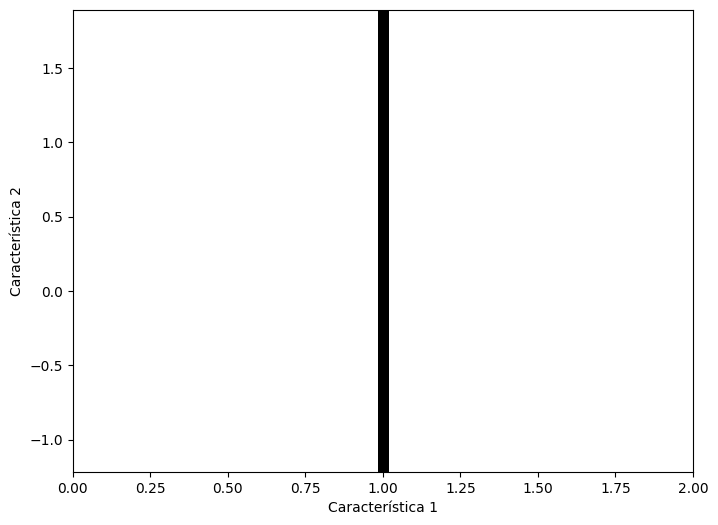

Valores únicos en la Columna 1: [1.]
Valores únicos en la Columna 2: [-1.2159004  -1.21586757 -1.21583474 ...  1.89175428  1.89178711
  1.89181994]


In [144]:
plt.figure(figsize=(8, 6))
plotDecisionBoundary(plotData, theta, X, y)
plt.show()
print("Valores únicos en la Columna 1:", np.unique(X[:, 1]))
print("Valores únicos en la Columna 2:", np.unique(X[:, 2]))

<a id="section4"></a>
#### 1.2.4 Evaluación de la regresión logistica

Después de aprender los parámetros, se puede usar el modelo para predecir si un estudiante en particular será admitido. Para un estudiante con una puntuación en el Examen 1 de 45 y una puntuación en el Examen 2 de 85, debe esperar ver una probabilidad de admisión de 0,776. Otra forma de evaluar la calidad de los parámetros que hemos encontrado es ver qué tan bien predice el modelo aprendido en nuestro conjunto de entrenamiento.

In [150]:
def predict(theta, X):
    """
    Predecir si la etiqueta es 0 o 1 usando el parámetro theta optimizado.
    Si la probabilidad es >= 0.5 predice 1, de lo contrario predice 0.
    """
    m = X.shape[0]
    p = np.zeros(m)

    # Calcular la probabilidad con la función sigmoide
    prob = sigmoid(X.dot(theta))

    # Convertir probabilidades a 0 o 1 usando el umbral 0.5
    p = (prob >= 0.5).astype(int)

    return p

# 1. Calcular las predicciones para el dataset X
p = predict(theta, X)

# 2. Calcular la precisión (porcentaje de aciertos)
accuracy = np.mean(p == y) * 100

print(f'Precisión en el conjunto de entrenamiento: {accuracy:.2f}%')
print('Precisión esperada (aproximada en plantilla): 89.00%')

Precisión en el conjunto de entrenamiento: 100.00%
Precisión esperada (aproximada en plantilla): 89.00%


Una vez entrenado el modelo se procede a realizar la prediccion y evaluación de los resultados de predecir cual es el valor que vota el modelo para todos los datos utilizados en el entrenamiento.

In [152]:
#  Predice la probabilidad de ingreso para un estudiante con nota de 45 en el examen 1 y nota de 85 en el examen 2
p = sigmoid(np.dot([1, 47, 77, 0], theta))
print('Para un estudiante con notas de 45 y 85, se predice una probabilidad de admisión de: {:.3f}%'.format(prob))
print('Valor esperado: 0.775 +/- 0.002\n')

# Compute accuracy on our training set
p = predict(theta, X)
print('Precisión de entrenamiento: {:.2f} %'.format(np.mean(p == y) * 100))
print('Precisión esperada (aproximadamente): 89.00 %')

Para un estudiante con notas de 45 y 85, se predice una probabilidad de admisión de: 1.000%
Valor esperado: 0.775 +/- 0.002

Precisión de entrenamiento: 100.00 %
Precisión esperada (aproximadamente): 89.00 %
